In [51]:
import torch
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import CIFAR100
from pathlib import Path
import os
from PIL import Image
import matplotlib.pyplot as plt
import random

In [52]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [53]:
train_transform = transforms.Compose([transforms.Resize((32,32)), transforms.RandomHorizontalFlip(p=0.5), transforms.RandomRotation(15),
                               transforms.RandomCrop(32,padding=4,padding_mode='reflect'),transforms.ToTensor()])
test_transform = transforms.Compose([transforms.Resize((32,32)), transforms.ToTensor()])

In [54]:
train_data = CIFAR100(root='data', train=True, download=True, transform=train_transform)
test_data = CIFAR100(root='data', train=False, download=True, transform=test_transform)

In [55]:
train_dataloader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=0)
test_dataloader = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=0)

In [56]:
class CifarModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Sequential(nn.Conv2d(3,32,kernel_size=3,padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.Conv2d(32,32,kernel_size=3,padding=1), 
                                    nn.BatchNorm2d(32),nn.ReLU(), nn.Dropout(p=0.25),nn.MaxPool2d(kernel_size=2))
        self.layer2 = nn.Sequential(nn.Conv2d(32,64,kernel_size=3,padding=1), nn.BatchNorm2d(64),nn.ReLU(), nn.Conv2d(64,64,kernel_size=3,padding=1), 
                                    nn.BatchNorm2d(64),nn.ReLU(), nn.Dropout(p=0.25),nn.MaxPool2d(kernel_size=2))
        self.layer3 = nn.Sequential(nn.Flatten(), nn.Dropout(p=0.5), nn.Linear(64*8*8, 512), nn.BatchNorm1d(512),
                                    nn.ReLU(), nn.Linear(512,100))
    def forward(self, x):
        x1 = self.layer1(x)
        x2 = self.layer2(x1)
        return self.layer3(x2)
model = CifarModel().to(device)

In [57]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

In [58]:
scheduler = torch.optim.lr_scheduler.StepLR(optimizer,step_size=20,gamma=0.35)

In [59]:
def acc_fn(pred,y):
    pred = pred.argmax(dim=1)
    acc = torch.eq(pred,y).sum().item()/len(pred)
    return acc*100

In [60]:
def train_step(model,dataloader=train_dataloader,loss_fn=loss_fn,optimizer=optimizer,device=device):
    model.train()
    acc = 0
    floss = 0
    for X,y in dataloader:
        X,y = X.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(X)
        loss = loss_fn(logits,y)
        loss.backward()
        optimizer.step()
        acc += acc_fn(logits, y)
        floss +=loss.item()
    return floss / len(dataloader), acc / len(dataloader)

def test_step(model,dataloader=test_dataloader,loss_fn=loss_fn, device=device):
    model.eval()
    acc = 0
    floss = 0
    with torch.inference_mode():
        for X,y in dataloader:
            X,y = X.to(device), y.to(device)
            logits = model(X)
            loss = loss_fn(logits,y)
            acc += acc_fn(logits, y)
            floss += loss.item()
        return floss / len(dataloader), acc / len(dataloader)



In [61]:
for epoch in range(51):
    train_loss, train_acc = train_step(model,optimizer=optimizer)
    test_loss, test_acc = test_step(model)
    scheduler.step()
    print(f'Epoch {epoch}\nTrain loss: {train_loss} Test loss: {test_loss}\nTrain acc:{train_acc} Test acc: {test_acc}')

Epoch 0
Train loss: 3.523472664986218 Test loss: 3.203096493364523
Train acc:16.488723608445298 Test acc: 22.44408945686901
Epoch 1
Train loss: 2.994024179871084 Test loss: 2.812895466344425
Train acc:25.585812539987206 Test acc: 30.471246006389777
Epoch 2
Train loss: 2.751296864132506 Test loss: 2.6491540872250883
Train acc:30.55022392834293 Test acc: 32.43809904153355
Epoch 3
Train loss: 2.5866925630978264 Test loss: 2.4241319616762596
Train acc:33.76919385796545 Test acc: 37.47004792332268
Epoch 4
Train loss: 2.4591863011978257 Test loss: 2.2867474007530335
Train acc:36.26839411388356 Test acc: 40.814696485623
Epoch 5
Train loss: 2.3626999987750503 Test loss: 2.1806805606086415
Train acc:38.66762635956494 Test acc: 42.74161341853035
Epoch 6
Train loss: 2.280992341361897 Test loss: 2.1902694641210783
Train acc:40.20113563659629 Test acc: 42.052715654952074
Epoch 7
Train loss: 2.214906108661561 Test loss: 2.0444367510823014
Train acc:41.8426103646833 Test acc: 46.25599041533546
Epoch 

In [62]:
torch.save(model.state_dict(), 'model_weights.pth')

In [63]:
model2 = CifarModel()
state_dict = torch.load('model_weights.pth',map_location=device)
model2.load_state_dict(state_dict=state_dict)

<All keys matched successfully>

In [64]:
classes = train_data.classes

Prediction: rabbit
Label: wolf


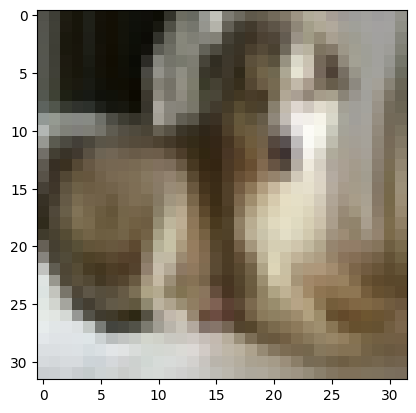

In [65]:
model2.eval()
with torch.inference_mode():
    img, label = test_data[random.randint(0,len(test_data)-1)]
    logits = model2(img.unsqueeze(dim=0))
    prediction = torch.argmax(logits,dim=1)
    plt.imshow(img.permute(1,2,0))
    print(f'Prediction: {classes[prediction.item()]}\nLabel: {classes[label]}')